# Sampel 3, Motif Separuh Lingkaran

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [19]:
line = cv2.imread("sampel-3_motif-separuh-lingkaran-2.PNG")
line_binary = binarize(line)
semicircle = cv2.imread("sampel-3_motif-separuh-lingkaran.PNG")
semicircle_binary = binarize(semicircle)

line_binary.shape

(2826, 3200)

array([  0, 255], dtype=uint8)

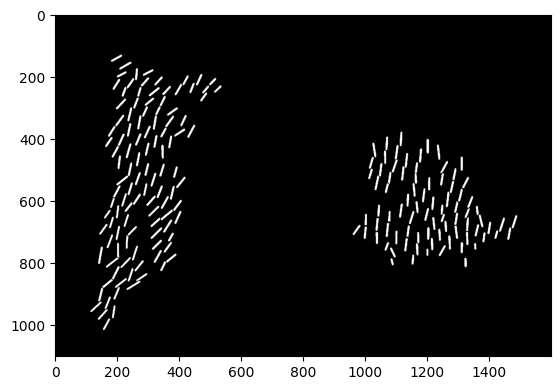

In [13]:
plt.imshow(line_binary[0:1100, 0:1600], cmap="grey")

np.unique(line_binary)

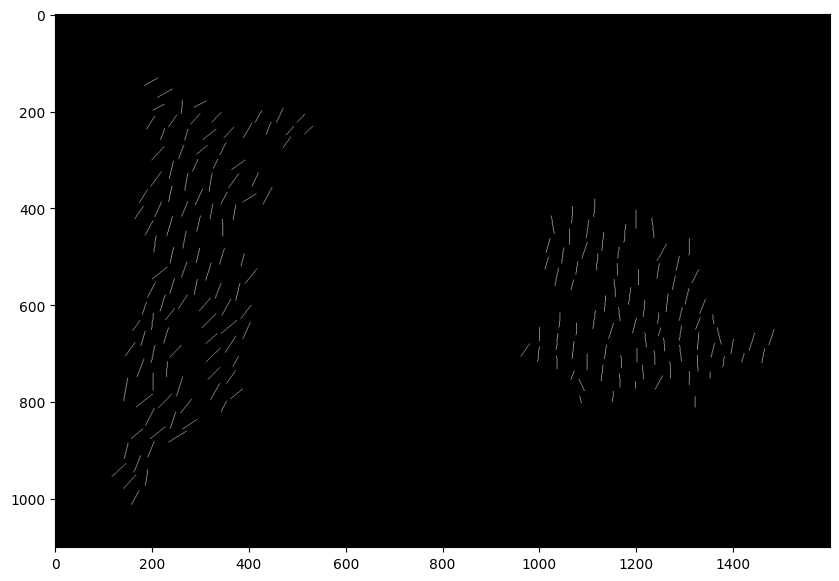

In [14]:
line_skeleton_image, line_skan = skeletonize(smoothBinary(line_binary))

plt.figure(figsize=(10, 10))
plt.imshow(line_skeleton_image[0:1100, 0:1600], cmap="grey")

## Orientasi Motif

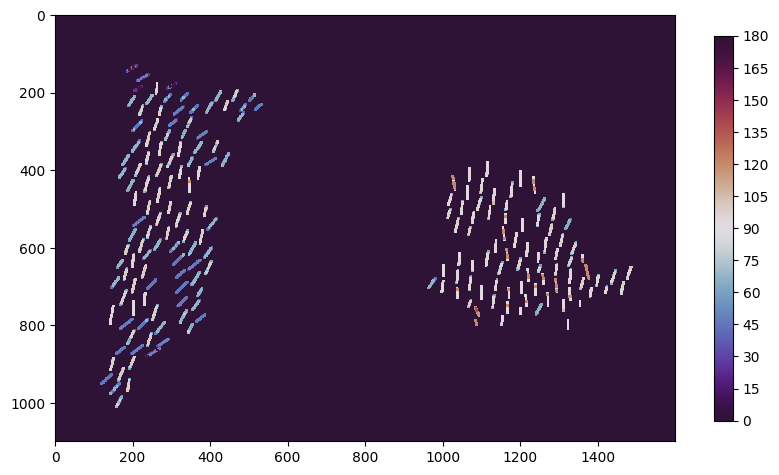

In [15]:
line_orientation_map = np.rad2deg(mapBranchOrientation(line_skeleton_image, line_skan, 5))
line_orientation_map_test = (line_orientation_map + 0)
line_orientation_map_test[np.isnan(line_orientation_map_test)] = 0
line_orientation_map_test = cv2.dilate(line_orientation_map_test, np.ones((3, 3), np.uint8), iterations=3)

plt.figure(figsize=(10, 10))
plt.imshow(line_orientation_map_test[0:1100, 0:1600], cmap='twilight_shifted', vmin=0, vmax=180, interpolation='nearest')
colorbar = plt.colorbar(shrink=0.5)

colorbar.set_ticks(range(0, 181, 15))

In [16]:
orientations = np.zeros(line_skan.n_paths, np.float64)

line_map = line_skan.path_label_image()

for line_id in range(1, line_skan.n_paths):
    line_orientation = line_orientation_map[line_map == line_id]
    orientations[line_id] = np.mean(line_orientation[~np.isnan(line_orientation)])

orientations

array([  0.        ,  40.80230394,  29.16399604,  86.72617657,
        53.62577962,  41.42155193,  65.9826735 ,  61.56960576,
        47.0089525 ,  48.82657619,  49.05311219,  57.90315604,
        59.75713697,  73.55041346,  58.52032392,  46.03826087,
        42.77513563,  46.9132881 ,  69.54077218,  75.25786875,
        36.57172972,  54.74587598,  63.60348705,  73.47091593,
        36.4782868 ,  47.73804193,  65.29272453,  64.20286295,
        34.00798341,  77.33815283,  54.9843996 ,  69.36278249,
        80.2590393 ,  80.78557772,  57.02746872,  76.9516252 ,
        62.96247502,  66.92078513,  60.20682704,  60.44964865,
        32.95063212,  87.16746717,  69.06780032,  70.16460981,
        79.69565624,  83.67828538,  56.43515768,  86.90996419,
        90.        ,  79.85189161,  99.93366979,  73.98371131,
        95.09855909,  91.4995762 ,  83.51194509,  61.97884835,
        82.0364115 ,  90.        ,  81.52810901,  85.94615117,
        83.81992837,  75.60224038,  88.66913521,  72.65

Text(0.5, 1.0, 'Branch Orientations')

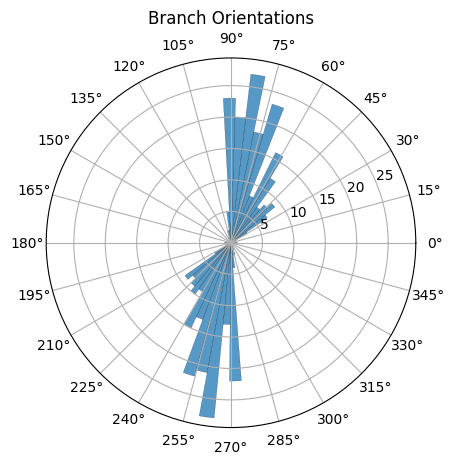

In [17]:
orientations_repeated = np.concatenate((orientations, orientations + 180))

# plt.figure(figsize=(10,10))
ax = plt.axes(projection="polar")
ax.set_xticks(np.arange(0, np.pi*2, np.pi/12))
sns.histplot(orientations_repeated / 180 * np.pi, ax=ax, bins=60)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Branch Orientations")

In [18]:
summarizeData(orientations, "Semicircle Orientations")

DATA SUMMARY of [Semicircle Orientations]:
Num     : 193
Mean    : 70.7273
SD      : 18.0555
SD rel  : 25.53%
Median  : 73.9113
MAD     : 11.9325
MAD rel : 16.14%
Min     : 0.0000
Max     : 113.8924



{'num': 193,
 'mean': 70.72733769410087,
 'sd': 18.05545794007833,
 'median': 73.91129984604453,
 'mad': 11.932451493112346,
 'min': 0.0,
 'max': 113.89236760787263}

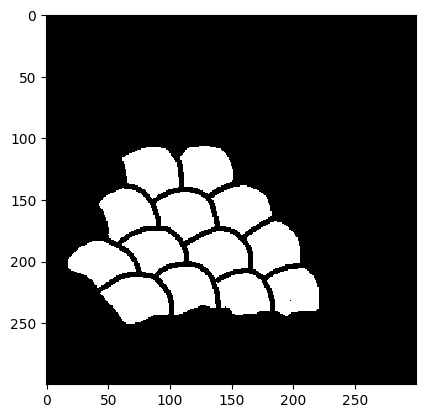

In [27]:
plt.imshow(semicircle_binary[1300:1600, 400:700], cmap='grey', interpolation='nearest')

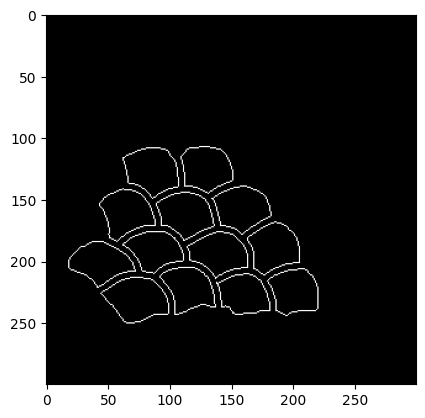

In [29]:
semicircle_contour = extractContours(semicircle_binary)
semicircle_contour_map = createContourMap(semicircle_binary.shape, semicircle_contour)

plt.imshow(semicircle_contour_map[1300:1600, 400:700], cmap='grey')

In [30]:
semicircle_contour_interpolated = interpolateContours(semicircle_contour, 100)
semicircle_mean_shape, semicircle_contours_rotated = processGPA(semicircle_contour_interpolated)

5.438156235380818e-06


In [31]:
semicircle_procrustes_distances = procrustesDistances(semicircle_mean_shape, semicircle_contours_rotated)
summarizeData(semicircle_procrustes_distances, "Procrustes Analysis")

DATA SUMMARY of [Procrustes Analysis]:
Num     : 13
Mean    : 0.0875
SD      : 0.0155
SD rel  : 17.68%
Median  : 0.0836
MAD     : 0.0116
MAD rel : 13.86%
Min     : 0.0681
Max     : 0.1159



{'num': 13,
 'mean': 0.08751911430033349,
 'sd': 0.01547577868947792,
 'median': 0.08361318455281697,
 'mad': 0.011591626480083689,
 'min': 0.06805682336981307,
 'max': 0.11586127693547617}

In [32]:
semicircle_contour_areas = contourAreas(semicircle_contour)
summarizeData(np.sqrt(semicircle_contour_areas), "Big Variant Rooted Areas")

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 13
Mean    : 34.4876
SD      : 1.2515
SD rel  : 3.63%
Median  : 34.5398
MAD     : 0.5885
MAD rel : 1.70%
Min     : 32.4114
Max     : 37.1954



{'num': 13,
 'mean': 34.487609688007744,
 'sd': 1.2515256566181223,
 'median': 34.539832078341085,
 'mad': 0.5885040621595081,
 'min': 32.41141774128371,
 'max': 37.19542982679458}

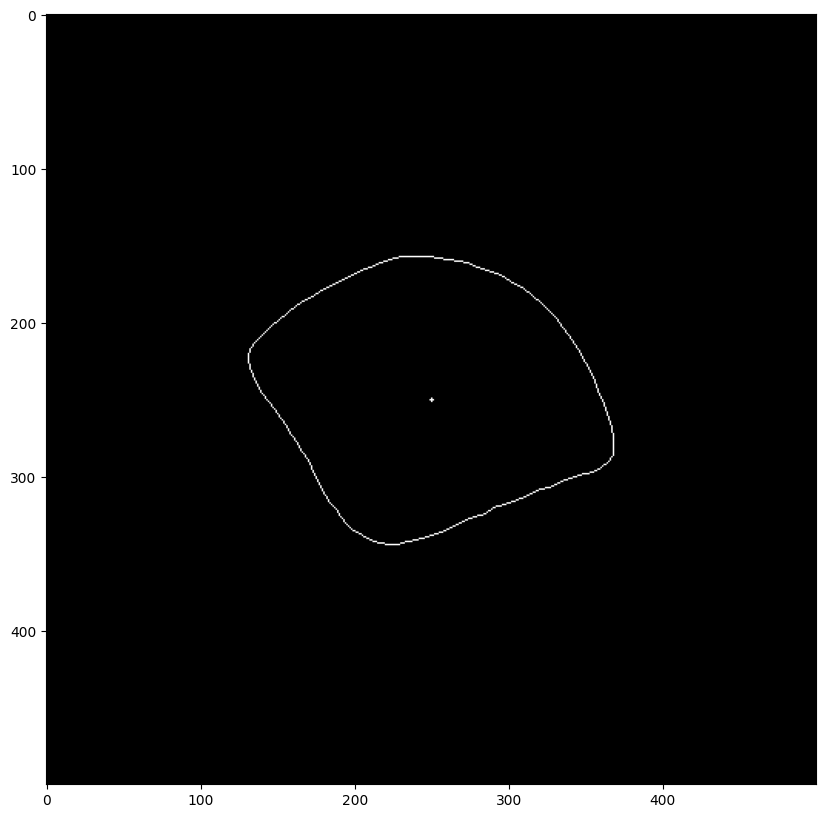

In [33]:
semicircle_size_factor = 1000

semicircle_mean_shape_binary = drawStandardizedContour((500, 500), semicircle_mean_shape, semicircle_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(semicircle_mean_shape_binary, cmap='gray')

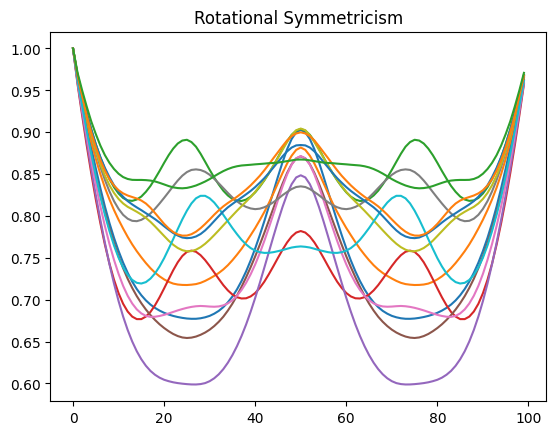

In [34]:
plt.title("Rotational Symmetricism")
for shape in semicircle_contours_rotated:
    sns.lineplot(testRotationalSymmetry(shape))

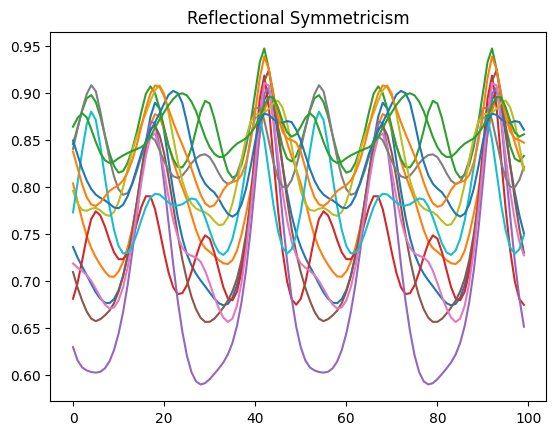

In [35]:
plt.title("Reflectional Symmetricism")
for shape in semicircle_contours_rotated:
    sns.lineplot(testReflectionalSymmetry(shape))